In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [12]:
df = pd.DataFrame({
    'Age':        [25, 32, 47, 51, 23, 36, 29, 44, 38, 55],
    'Salary':     [45000, 85000, 120000, 95000, 38000, 72000, 50000, 110000, 78000, 130000],
    'Experience': [2, 8, 20, 22, 1, 10, 4, 18, 12, 25],
    'Promoted':   [0, 1, 1, 1, 0, 1, 0, 1, 1, 1]
})

df

,Age,Salary,Experience,Promoted
0,25,45000,2,0
1,32,85000,8,1
2,47,120000,20,1
3,51,95000,22,1
4,23,38000,1,0
5,36,72000,10,1
6,29,50000,4,0
7,44,110000,18,1
8,38,78000,12,1
9,55,130000,25,1


In [13]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Age         10 non-null     int64
 1   Salary      10 non-null     int64
 2   Experience  10 non-null     int64
 3   Promoted    10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


In [16]:
print(f"""
Scale comparison:
  Age range:        {df['Age'].min()} – {df['Age'].max()}
  Salary range:      {df['Salary'].min()} – {df['Salary'].max()}
  Experience range:  {df['Experience'].min()} – {df['Experience'].max()}

Without scaling, Salary (range ~90,000) would dominate distance calculations
over Age (range ~30) and Experience (range ~24) — even if Age and Experience
matter just as much for the prediction.
""")


Scale comparison:
  Age range:        23 – 55
  Salary range:      38000 – 130000
  Experience range:  1 – 25

Without scaling, Salary (range ~90,000) would dominate distance calculations
over Age (range ~30) and Experience (range ~24) — even if Age and Experience
matter just as much for the prediction.



#Min-Max Scaling

In [17]:
features = ['Age', 'Salary', 'Experience']
X = df[features].copy()

mm_scaler = MinMaxScaler()
X_mm = pd.DataFrame(mm_scaler.fit_transform(X), columns=features)

print(f'Min-Max Scaled: \n{X_mm}')
print(f'\nMin of each column should be: \n{X_mm.min()}')
print(f'\nMax of each column should be: \n{X_mm.max()}')

print("""
Min-Max Scaling — Pros & Cons:
  + Bounded range, good for neural networks (sigmoid/tanh activations)
  + Preserves relationships between original values
  - Very sensitive to outliers — a single extreme value compresses everything else
""")

Min-Max Scaled: 
       Age    Salary  Experience
0  0.06250  0.076087    0.041667
1  0.28125  0.510870    0.291667
2  0.75000  0.891304    0.791667
3  0.87500  0.619565    0.875000
4  0.00000  0.000000    0.000000
5  0.40625  0.369565    0.375000
6  0.18750  0.130435    0.125000
7  0.65625  0.782609    0.708333
8  0.46875  0.434783    0.458333
9  1.00000  1.000000    1.000000

Min of each column should be: 
Age           0.0
Salary        0.0
Experience    0.0
dtype: float64

Max of each column should be: 
Age           1.0
Salary        1.0
Experience    1.0
dtype: float64

Min-Max Scaling — Pros & Cons:
  + Bounded range, good for neural networks (sigmoid/tanh activations)
  + Preserves relationships between original values
  - Very sensitive to outliers — a single extreme value compresses everything else



#Standardization (Z-Score Scaling)

In [19]:
std_scaler = StandardScaler()
X_std = pd.DataFrame(std_scaler.fit_transform(X), columns=features)

print(f'Standardized: \n{X_std}')
print(f'\nMean of each column should be: \n{X_std.mean()}')
print(f'\nStandard deviation of each column should be: \n{X_std.std()}')

print("""
Standardization — Pros & Cons:
  + Not bounded to a fixed range — works well with algorithms assuming normal distribution
  + Less sensitive to outliers than Min-Max (but still affected)
  + Preferred default for Linear Regression, Logistic Regression, SVM, PCA
  - Doesn't guarantee a specific range, can be a problem for some neural net activations
""")

Standardized: 
        Age    Salary  Experience
0 -1.245174 -1.232824   -1.242794
1 -0.574696  0.089239   -0.511739
2  0.862044  1.246044    0.950372
3  1.245174  0.419755    1.194057
4 -1.436739 -1.464185   -1.364637
5 -0.191565 -0.340431   -0.268054
6 -0.862044 -1.067566   -0.999109
7  0.574696  0.915529    0.706687
8  0.000000 -0.142122   -0.024369
9  1.628305  1.576560    1.559585

Mean of each column should be: 
Age          -2.220446e-17
Salary        0.000000e+00
Experience    4.440892e-17
dtype: float64

Standard deviation of each column should be: 
Age           1.054093
Salary        1.054093
Experience    1.054093
dtype: float64

Standardization — Pros & Cons:
  + Not bounded to a fixed range — works well with algorithms assuming normal distribution
  + Less sensitive to outliers than Min-Max (but still affected)
  + Preferred default for Linear Regression, Logistic Regression, SVM, PCA
  - Doesn't guarantee a specific range, can be a problem for some neural net activations

#RobustScaler (outlier-resistant)

In [21]:
robust_scaler = RobustScaler()
X_robust = pd.DataFrame(robust_scaler.fit_transform(X), columns=features)

print(f'\nRobust Sclaed: {X_robust}')
print(f'\nMin of each column should be: \n{X_robust.min()}')
print(f'\nMax of each column should be: \n{X_robust.max()}')


Robust Sclaed:         Age    Salary  Experience
0 -0.727273 -0.719212   -0.620690
1 -0.303030  0.068966   -0.206897
2  0.606061  0.758621    0.620690
3  0.848485  0.266010    0.758621
4 -0.848485 -0.857143   -0.689655
5 -0.060606 -0.187192   -0.068966
6 -0.484848 -0.620690   -0.482759
7  0.424242  0.561576    0.482759
8  0.060606 -0.068966    0.068966
9  1.090909  0.955665    0.965517

Min of each column should be: 
Age          -0.848485
Salary       -0.857143
Experience   -0.689655
dtype: float64

Max of each column should be: 
Age           1.090909
Salary        0.955665
Experience    0.965517
dtype: float64


/tmp/ipykernel_8248/1020571733.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=features, patch_artist=True,
/tmp/ipykernel_8248/1020571733.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=features, patch_artist=True,
/tmp/ipykernel_8248/1020571733.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=features, patch_artist=True,


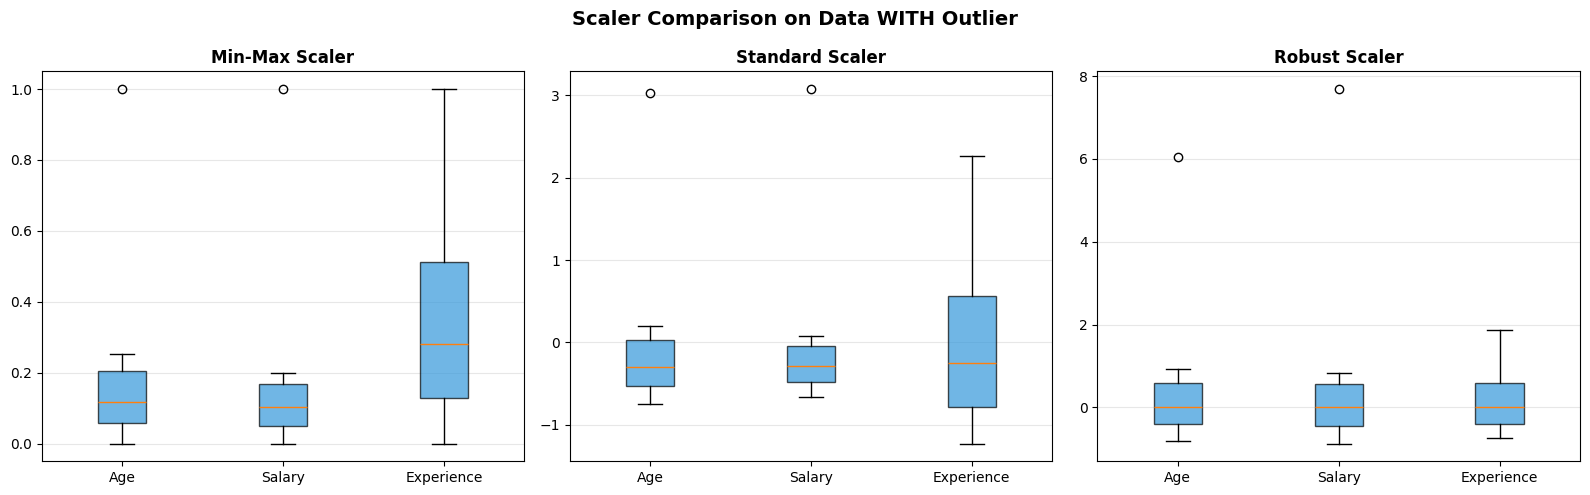

Salary scaled values (with outlier present):
    Original  MinMax  Standard  Robust
0      45000   0.015    -0.610  -0.741
1      85000   0.102    -0.286   0.000
2     120000   0.177    -0.002   0.648
3      95000   0.123    -0.205   0.185
4      38000   0.000    -0.666  -0.870
5      72000   0.074    -0.391  -0.241
6      50000   0.026    -0.569  -0.648
7     110000   0.156    -0.083   0.463
8      78000   0.087    -0.342  -0.130
9     130000   0.199     0.079   0.833
10    500000   1.000     3.075   7.685

Notice: MinMax compresses all normal values close to 0 because of the outlier.
Standard is also pulled by the outlier (mean and std are both affected).
Robust keeps normal values spread out — median and IQR ignore the extreme value.



In [22]:
df_outlier = df.copy()
df_outlier.loc[len(df_outlier)] = [150, 500000, 40, 1]  # extreme outlier row

X_out = df_outlier[features].copy()

# Compare all 3 scalers on outlier-contaminated data
mm = MinMaxScaler().fit_transform(X_out)
ss = StandardScaler().fit_transform(X_out)
rs = RobustScaler().fit_transform(X_out)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Scaler Comparison on Data WITH Outlier', fontsize=14, fontweight='bold')

for i, (data, title) in enumerate(zip([mm, ss, rs], ['Min-Max', 'Standard', 'Robust'])):
    axes[i].boxplot(data, labels=features, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7))
    axes[i].set_title(f'{title} Scaler', fontweight='bold')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('scaler_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Salary scaled values (with outlier present):")
print(pd.DataFrame({
    'Original': X_out['Salary'].values,
    'MinMax':   mm[:, 1].round(3),
    'Standard': ss[:, 1].round(3),
    'Robust':   rs[:, 1].round(3)
}))

print("""
Notice: MinMax compresses all normal values close to 0 because of the outlier.
Standard is also pulled by the outlier (mean and std are both affected).
Robust keeps normal values spread out — median and IQR ignore the extreme value.
""")

#Impact on Model Performance

In [25]:
X = df[features]
y = df['Promoted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#without scaling
knn_raw = KNeighborsClassifier(n_neighbors=3)
knn_raw.fit(X_train, y_train)
acc_raw = accuracy_score(y_test, knn_raw.predict(X_test))
print(f'Accuracy without scaling: {acc_raw:.2f}')

Accuracy without scaling: 1.00


In [26]:
#With Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=3)
knn_scaled.fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_scaled))
print(f'Accuracy with scaling: {acc_scaled:.2f}')

Accuracy with scaling: 0.50


In [28]:
print("""
CRITICAL RULE: Always fit the scaler on TRAINING data only, then transform
both train and test sets using that same fitted scaler.

WRONG:  scaler.fit_transform(X_train), scaler.fit_transform(X_test)
RIGHT:  scaler.fit_transform(X_train), scaler.transform(X_test)

Fitting on test data causes data leakage — the model indirectly "sees"
test set statistics during training, inflating performance metrics.
""")

print("""
╔══════════════════╦═══════════════════════════╦═══════════════════════════╗
║ Scaler           ║ Use When                  ║ Avoid When                ║
╠══════════════════╬═══════════════════════════╬═══════════════════════════╣
║ MinMaxScaler     ║ Bounded range needed      ║ Outliers present          ║
║                  ║ (neural nets, images)     ║                           ║
╠══════════════════╬═══════════════════════════╬═══════════════════════════╣
║ StandardScaler   ║ Linear/Logistic Reg, SVM, ║ Heavy outliers, data not  ║
║                  ║ PCA, default choice       ║ normally distributed      ║
╠══════════════════╬═══════════════════════════╬═══════════════════════════╣
║ RobustScaler     ║ Data has known outliers   ║ Clean, outlier-free data  ║
╚══════════════════╩═══════════════════════════╩═══════════════════════════╝
""")


CRITICAL RULE: Always fit the scaler on TRAINING data only, then transform
both train and test sets using that same fitted scaler.

WRONG:  scaler.fit_transform(X_train), scaler.fit_transform(X_test)
RIGHT:  scaler.fit_transform(X_train), scaler.transform(X_test)

Fitting on test data causes data leakage — the model indirectly "sees"
test set statistics during training, inflating performance metrics.


╔══════════════════╦═══════════════════════════╦═══════════════════════════╗
║ Scaler           ║ Use When                  ║ Avoid When                ║
╠══════════════════╬═══════════════════════════╬═══════════════════════════╣
║ MinMaxScaler     ║ Bounded range needed      ║ Outliers present          ║
║                  ║ (neural nets, images)     ║                           ║
╠══════════════════╬═══════════════════════════╬═══════════════════════════╣
║ StandardScaler   ║ Linear/Logistic Reg, SVM, ║ Heavy outliers, data not  ║
║                  ║ PCA, default choice       ║ norma